In [1]:
import json

LANGUAGES = ("java", "python")
LEVELS = ("signature", "context")
MODELS = {
    "gpt-5.4": "GPT-5.4",
    "deepseek-v4-pro": "DeepSeek V4 Pro",
    "deepseek-v4-flash": "DeepSeek V4 Flash",
    "glm-5.1": "GLM-5.1",
}


def load_jsonl(path):
    rows = []
    with open(path, encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            if not line.strip():
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as error:
                raise ValueError(f"Invalid JSON at {path}:{line_number}") from error
    return rows


def load_latest_results(language, level, model):
    path = f"../benchmark/llm_evaluation/{language}_{level}_{model}.jsonl"
    latest = {}
    for row in load_jsonl(path):
        latest[row["query_id"]] = row
    failures = [row for row in latest.values() if row.get("request_error") is not None]
    if failures:
        raise ValueError(f"{path} contains {len(failures)} unresolved request failures")
    return latest


def load_all_results():
    res = {}
    for lang in LANGUAGES:
        for level in LEVELS:
            for model in MODELS:
                res[(lang, level, model)] = load_latest_results(lang, level, model)
    return res


llm_results = load_all_results()

In [2]:
import re
import pandas as pd


def java_fqn(signature):
    if not isinstance(signature, str):
        return None
    return re.sub(r"\s+", "", signature).partition("(")[0]


def java_fqn_correct(row):
    prediction = row.get("normalized_prediction")
    return java_fqn(prediction) == java_fqn(row["reference_replacement"])


def exact_accuracy(rows):
    rows = list(rows)
    return 100 * sum(bool(row.get("exact_match")) for row in rows) / len(rows)


def build_overall_accuracy_table():
    records = []
    for model, display_name in MODELS.items():
        java_signature = llm_results.get(("java", "signature", model))
        java_context = llm_results.get(("java", "context", model))
        python_signature = llm_results.get(("python", "signature", model))
        python_context = llm_results.get(("python", "context", model))

        records.append(
            {
                "Model": display_name,
                "Java signature FQN": 100
                * sum(java_fqn_correct(row) for row in java_signature.values())
                / len(java_signature),
                "Java signature full": exact_accuracy(java_signature.values()),
                "Java context FQN": 100
                * sum(java_fqn_correct(row) for row in java_context.values())
                / len(java_context),
                "Java context full": exact_accuracy(java_context.values()),
                "Python signature FQN": exact_accuracy(python_signature.values()),
                "Python context FQN": exact_accuracy(python_context.values()),
            }
        )

    table = pd.DataFrame(records)
    # table.to_csv("../benchmark/evaluation/rq3_overall_accuracy.csv", index=False)
    return table.round(1)


build_overall_accuracy_table()

,Model,Java signature FQN,Java signature full,Java context FQN,Java context full,Python signature FQN,Python context FQN
0,GPT-5.4,37.1,27.5,36.1,26.5,42.5,44.4
1,DeepSeek V4 Pro,32.1,24.2,31.0,22.2,36.4,36.1
2,DeepSeek V4 Flash,25.7,21.2,25.8,20.6,30.0,29.1
3,GLM-5.1,26.2,23.2,25.3,21.7,32.5,32.2


In [3]:
from scipy.stats import binomtest


def holm_adjust(p_values):
    order = sorted(range(len(p_values)), key=p_values.__getitem__)
    adjusted = [0.0] * len(p_values)
    previous = 0.0
    for rank, index in enumerate(order):
        current = min(1.0, (len(p_values) - rank) * p_values[index])
        previous = max(previous, current)
        adjusted[index] = previous
    return adjusted


def build_paired_context_table():
    records = []
    for language in LANGUAGES:
        for model, display_name in MODELS.items():
            signature = llm_results.get((language, "signature", model))
            context = llm_results.get((language, "context", model))
            shared = sorted(set(signature).intersection(context))
            if len(shared) != len(signature) or len(shared) != len(context):
                raise ValueError(f"Unpaired examples for {language}, {model}")

            context_gain = sum(
                not signature[query_id]["exact_match"]
                and context[query_id]["exact_match"]
                for query_id in shared
            )
            context_loss = sum(
                signature[query_id]["exact_match"]
                and not context[query_id]["exact_match"]
                for query_id in shared
            )
            signature_accuracy = exact_accuracy(signature.values())
            context_accuracy = exact_accuracy(context.values())
            p_value = (
                binomtest(
                    min(context_gain, context_loss),
                    context_gain + context_loss,
                    p=0.5,
                    alternative="two-sided",
                ).pvalue
                if context_gain + context_loss
                else 1.0
            )
            records.append(
                {
                    "Language": language.capitalize(),
                    "Model": display_name,
                    "Signature accuracy": signature_accuracy,
                    "Context accuracy": context_accuracy,
                    "Delta": context_accuracy - signature_accuracy,
                    "Incorrect to correct": context_gain,
                    "Correct to incorrect": context_loss,
                    "p": p_value,
                }
            )

    table = pd.DataFrame(records)
    table["Holm adjusted p"] = holm_adjust(table["p"].tolist())
    # table.to_csv("../benchmark/evaluation/rq3_paired_context_analysis.csv", index=False)
    return table.round(
        {
            "Signature accuracy": 2,
            "Context accuracy": 2,
            "Delta": 2,
            "p": 4,
            "Holm adjusted p": 4,
        }
    )


build_paired_context_table()

,Language,Model,Signature accuracy,Context accuracy,Delta,Incorrect to correct,Correct to incorrect,p,Holm adjusted p
0,Java,GPT-5.4,27.47,26.45,-1.02,959,1145,0.0001,0.0003
1,Java,DeepSeek V4 Pro,24.20,22.23,-1.97,498,856,0.0000,0.0000
2,Java,DeepSeek V4 Flash,21.17,20.55,-0.62,598,710,0.0021,0.0085
3,Java,GLM-5.1,23.22,21.66,-1.57,794,1079,0.0000,0.0000
4,Python,GPT-5.4,42.52,44.36,1.83,294,214,0.0004,0.0022
5,Python,DeepSeek V4 Pro,36.44,36.12,-0.32,204,218,0.5269,1.0000
6,Python,DeepSeek V4 Flash,29.95,29.08,-0.87,170,208,0.0569,0.1707
7,Python,GLM-5.1,32.55,32.20,-0.34,211,226,0.5031,1.0000


In [4]:
def mapping_frequencies(language):
    frequencies = dict()
    for row in load_jsonl(f"../benchmark/llm_evaluation/{language}_update_pairs.jsonl"):
        mapping = (
            row["library"],
            row["legacy_api"],
            row["reference_replacement"],
        )
        frequencies[mapping] = frequencies.get(mapping, 0) + row["instances"]

    query_frequencies = {}
    sig_data_path = f"../benchmark/llm_evaluation/{language}_signature_level.jsonl"
    for row in load_jsonl(sig_data_path):
        mapping = (
            row["library"],
            row["legacy_api"],
            row["reference_replacement"],
        )
        query_frequencies[row["query_id"]] = frequencies[mapping]
    return query_frequencies


mapping_freq_data = {lang: mapping_frequencies(lang) for lang in LANGUAGES}

In [5]:
FREQUENCY_BINS = (
    ("1", lambda value: value == 1),
    ("2-5", lambda value: 2 <= value <= 5),
    ("6-10", lambda value: 6 <= value <= 10),
    ("11-100", lambda value: 11 <= value <= 100),
    (">100", lambda value: value > 100),
)


def build_frequency_counts_table():
    records = []
    for language in LANGUAGES:
        frequencies = mapping_freq_data.get(language)
        record = {"Language": language.capitalize()}
        for label, contains in FREQUENCY_BINS:
            record[label] = sum(contains(value) for value in frequencies.values())
        records.append(record)

    table = pd.DataFrame(records)
    # table.to_csv(
    #     "../benchmark/evaluation/rq3_mapping_frequency_counts.csv", index=False
    # )
    return table


build_frequency_counts_table()

,Language,1,2-5,6-10,11-100,>100
0,Java,7605,6868,1702,1758,233
1,Python,1614,1629,429,562,126


In [6]:
import math


def wilson_interval(correct, total, z=1.959963984540054):
    proportion = correct / total
    denominator = 1 + z * z / total
    center = (proportion + z * z / (2 * total)) / denominator
    margin = (
        z
        * math.sqrt(proportion * (1 - proportion) / total + z * z / (4 * total * total))
        / denominator
    )
    return 100 * (center - margin), 100 * (center + margin)

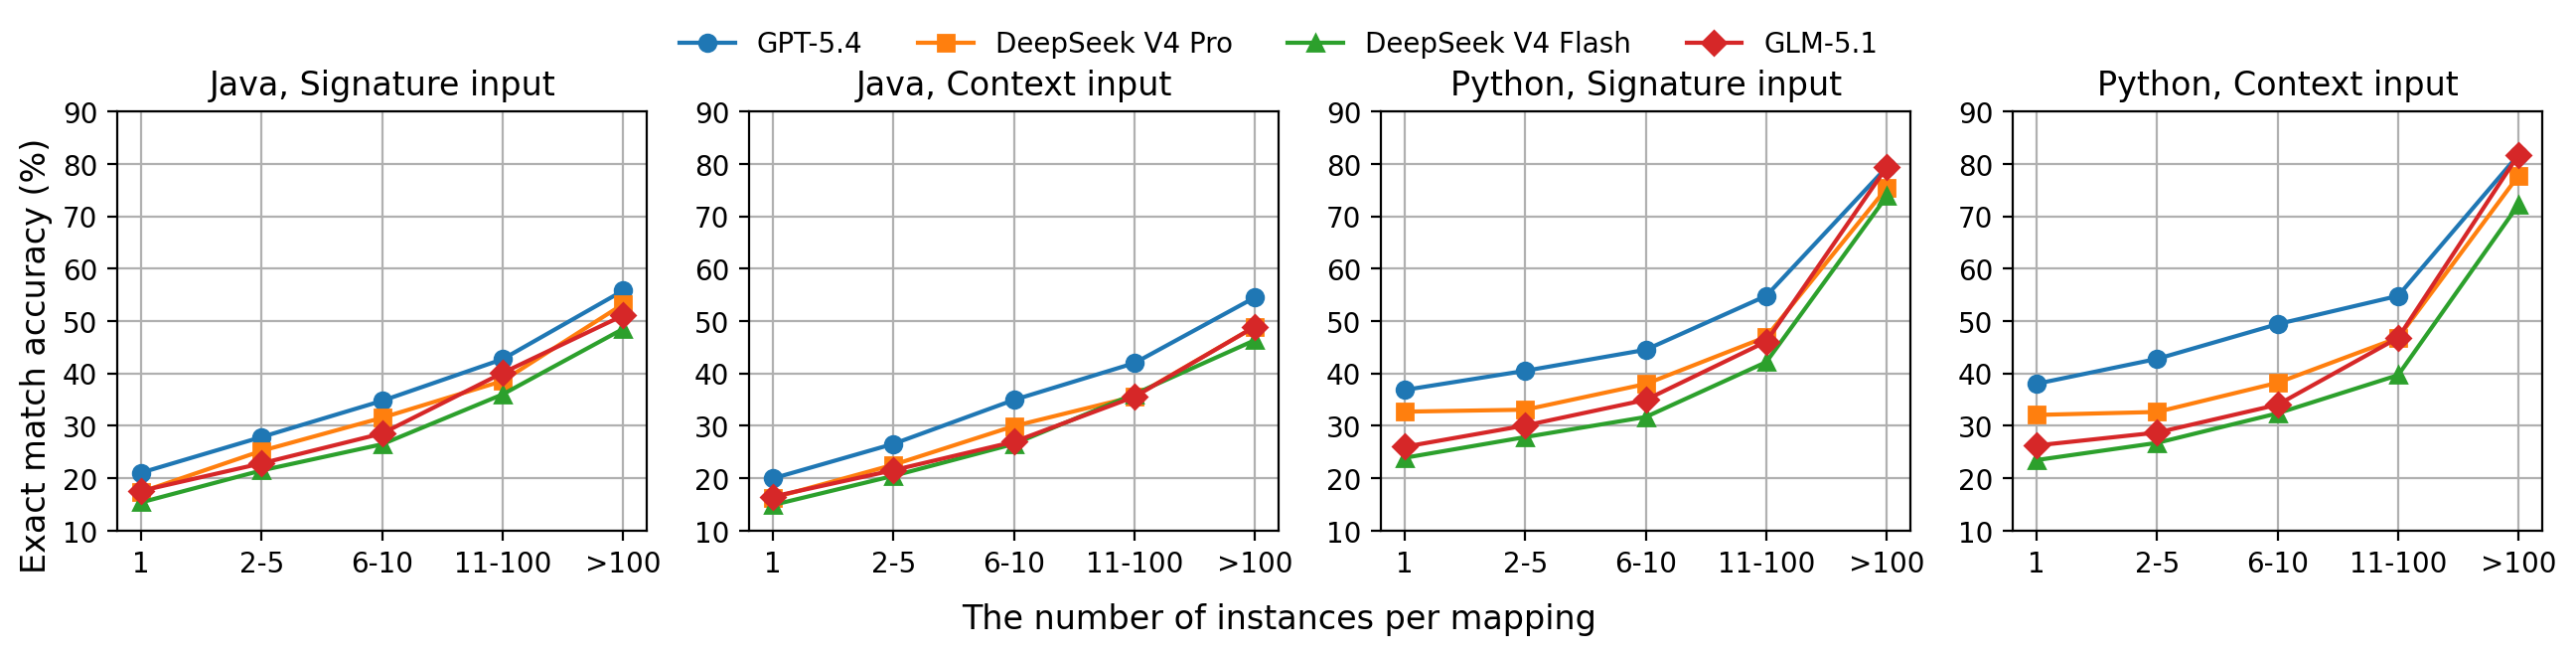

In [7]:
%matplotlib inline
%config InlineBackend.figure_format="retina"
import matplotlib.pyplot as plt

CMAP = plt.get_cmap("tab10")
COLORS = {
    "gpt-5.4": CMAP(0),
    "deepseek-v4-pro": CMAP(1),
    "deepseek-v4-flash": CMAP(2),
    "glm-5.1": CMAP(3),
}
MARKERS = {
    "gpt-5.4": "o",
    "deepseek-v4-pro": "s",
    "deepseek-v4-flash": "^",
    "glm-5.1": "D",
}


def plot_accuracy_by_mapping_frequency():
    fig, axes = plt.subplots(1, 4, figsize=(13.2, 3.2))

    for row_index, language in enumerate(LANGUAGES):
        frequencies = mapping_freq_data.get(language)
        counts = [
            sum(contains(value) for value in frequencies.values())
            for _, contains in FREQUENCY_BINS
        ]
        for column_index, level in enumerate(LEVELS):
            idx = row_index * len(LEVELS) + column_index
            axis = axes[idx]
            for model, display_name in MODELS.items():
                results = llm_results.get((language, level, model))
                accuracies = []
                # lower_errors = []
                # upper_errors = []
                for (_, contains), total in zip(FREQUENCY_BINS, counts):
                    selected = [
                        results[query_id]
                        for query_id, frequency in frequencies.items()
                        if contains(frequency)
                    ]
                    correct = sum(bool(result["exact_match"]) for result in selected)
                    accuracy = 100 * correct / total
                    # lower, upper = wilson_interval(correct, total)
                    accuracies.append(accuracy)
                    # lower_errors.append(accuracy - lower)
                    # upper_errors.append(upper - accuracy)

                axis.plot(
                    range(len(FREQUENCY_BINS)),
                    accuracies,
                    # yerr=[lower_errors, upper_errors],
                    color=COLORS[model],
                    marker=MARKERS[model],
                    # markersize=5,
                    # linewidth=1.8,
                    # capsize=2.5,
                    label=display_name,
                )

            axis.set_title(f"{language.capitalize()}, {level.capitalize()} input")
            axis.set_ylim(10, 90)
            axis.set_yticks(range(10, 91, 10))
            axis.set_yticklabels([f"{value}" for value in range(10, 91, 10)])
            axis.set_xticks(range(len(FREQUENCY_BINS)))
            axis.set_xticklabels([label for label, _ in FREQUENCY_BINS])
            # axis.set_ylabel("Exact match accuracy (%)")
            axis.set_ylabel(None)
            axis.set_xlabel(None)
            axis.grid()
    fig.supylabel("Exact match accuracy (%)")
    fig.align_ylabels()
    fig.supxlabel("The number of instances per mapping", y=0.06)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=4,
        frameon=False,
    )
    # fig.subplots_adjust(top=0.88, bottom=0.10, left=0.08, right=0.99, hspace=0.30, wspace=0.16)
    output_path = "../submission/figures/rq3_accuracy_by_mapping_frequency.pdf"
    plt.tight_layout()
    plt.show()
    fig.savefig(output_path, bbox_inches="tight")


plot_accuracy_by_mapping_frequency()